In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split

from warnings import filterwarnings
filterwarnings('ignore')

## Import Data

In [2]:
data_path = '../data/labeled.csv'
df = pd.read_csv(data_path)
print(df.shape)
df.head()

(14412, 2)


,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0
2,Собаке - собачья смерть\n,1.0
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0


## Target Distribution

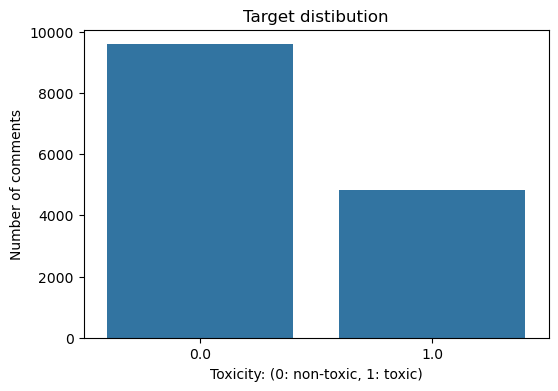

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='toxic', data=df)

plt.title('Target distibution')
plt.xlabel('Toxicity: (0: non-toxic, 1: toxic)')
plt.ylabel('Number of comments')
plt.show()

**Conclusion.** The dataset contains both toxic and non-toxic comments. The class distribution is moderately imbalanced, with non-toxic comments occurring approximately twice as often as toxic ones. Therefore, model evaluation should rely not only on Accuracy but also on Precision, Recall, and F1-score.

## Examples of comments

In [5]:
print("\nExamples of toxic comments:")
print(df[df['toxic'] == 1]['comment'].sample(5).tolist())
print("\nExamples of non-toxic comments:")
print(df[df['toxic'] == 0]['comment'].sample(5).tolist())


Examples of toxic comments:
['Алсо двачую за политику ужесточения, наберите моар модеров в тред и сметите весь этот мусор с их кирюхами, заводами, чумоходами и прочей не имеющей к треду отношения поеботой в 2д, пусть там в жопы долбятся.\n', 'Обязательно запихают в 3 часть негра, лезбиянку, фемку и трансов и прочий скам а главный герой будет баба мужик на половину азиат на половину негр\n', 'жалко на лицо не попало\n', 'у тебя что, ИНТОКСИКАЦИЯ УКРАИНСКИМ МИРОМ?\n', 'Бомбишь с куколдизма своей страны Аррррря ти кремлебот, ни слова плохого про Украину!!11\n']

Examples of non-toxic comments:
['Вот я как раз в Свердловской и нахожусь. Как топливо влияет на нормированное теплосопротивление стены, вопрос то был про то, зачем утеплять 375 блок? 375мм D500 в свердловской области не пройдёт никак без утепления не пройдёт по нормативу. И как вы решили D600 утеплять в итоге? Без утепления R 2,85 - очень слабенький результат\n', 'речь не про бабушкин масляный радиатор а про самые современные те

## Text analysis

### Data Quality

In [6]:
df['comment'].duplicated().sum()

np.int64(0)

In [7]:
df[df['comment'] == '']

,comment,toxic


In [8]:
df['comment'].isna().sum()

np.int64(0)

**Conclusion.** Data quality analysis revealed no empty comments, missing values and duplicates.

### Vocabulary size

In [9]:
vocab_size = len(set(" ".join(df['comment'].tolist()).split()))
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 103147


**Conclusion.** The dataset contains a relatively large vocabulary, indicating substantial lexical diversity. This increases the complexity of the classification task and motivates the use of models capable of capturing contextual information.

### Average number of words and unique words in comments

In [10]:
df['word_count'] = df['comment'].apply(lambda x: len(str(x).split()))
df['unique_word_count'] = df['comment'].apply(lambda x: len(set(str(x).split())))

print(f"Average number of words in a comment: {df['word_count'].mean()}")
print(f"Average number of unique words in a comment: {df['unique_word_count'].mean()}")
print()
print(f"Minimum number of words in a comment: {df['word_count'].min()}")
print(f"Maximum number of words in a comment: {df['word_count'].max()}")

Average number of words in a comment: 27.94601720788232
Average number of unique words in a comment: 24.99895920066611

Minimum number of words in a comment: 1
Maximum number of words in a comment: 1078


**Conclusion.** Most comments are relatively short and contain a limited number of words. The number of unique words is close to the total word count, indicating low token repetition within individual comments.

### Sentence length analysis (in words)

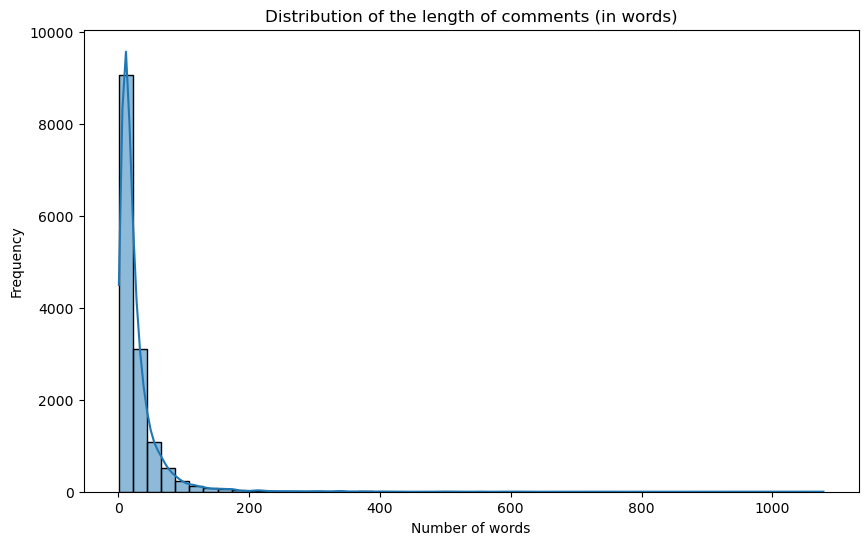

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Distribution of the length of comments (in words)')
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.show()

**Conclusion.** The comment length distribution is right-skewed: most comments are short, while a small number of unusually long comments are present. This should be taken into account when selecting the maximum sequence length for transformer-based models.

### Distribution of lengths by class

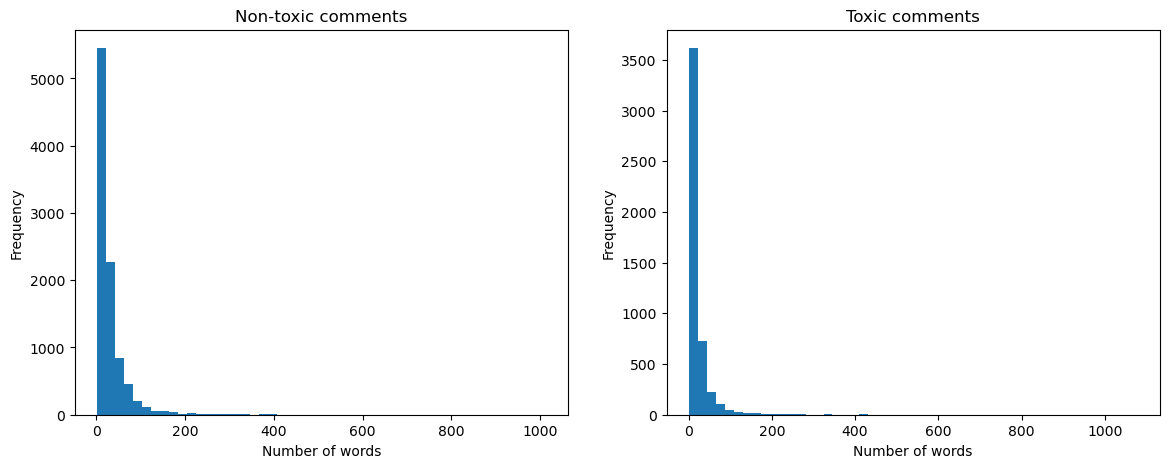

In [12]:
toxic = df[df['toxic'] == 1.0]['word_count']
non_toxic = df[df['toxic'] == 0.0]['word_count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(non_toxic, bins=50)
axes[0].set_title('Non-toxic comments')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Frequency')

axes[1].hist(toxic, bins=50)
axes[1].set_title('Toxic comments')
axes[1].set_xlabel('Number of words')
axes[1].set_ylabel('Frequency')

plt.show()

### Word Cloud (Warning - contains obscene vocabulary)

In [13]:
import json

stopwords_path = 'stopwords-ru.json'

with open(stopwords_path, "r", encoding="utf-8") as file:
    stop_w = json.load(file)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/elenasapunova/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


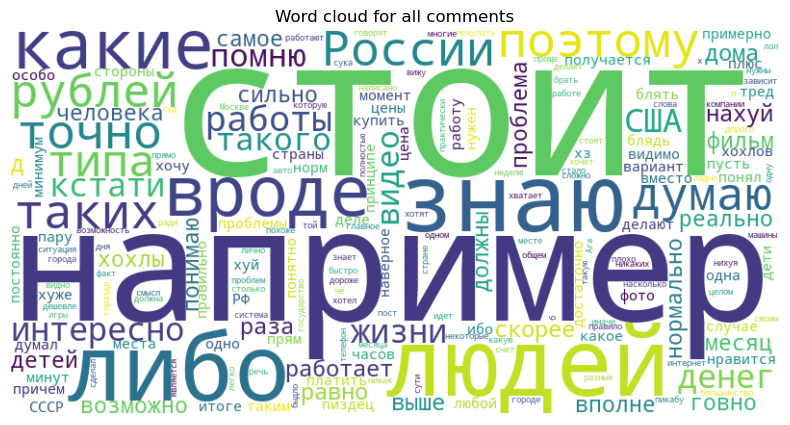

In [14]:
comments = " ".join(df['comment'].dropna().tolist())
nltk.download('stopwords')
nltk_stopwords = stopwords.words('russian')

stopwords_russian = list(set(nltk_stopwords + stop_w))
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords_russian).generate(comments)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word cloud for all comments')
plt.show()

Text(0.5, 1.0, 'Word Cloud for non-toxic comments')

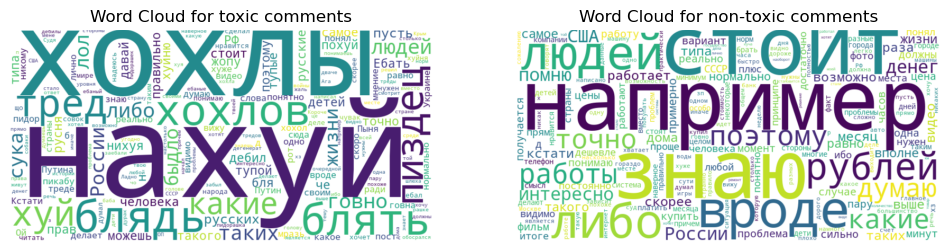

In [15]:
non_toxic_comments = " ".join(df[df['toxic'] == 0.0]['comment'].dropna().tolist())
toxic_comments = " ".join(df[df['toxic'] == 1.0]['comment'].dropna().tolist())

wordcloud_non_toxic = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords_russian).generate(non_toxic_comments)
wordcloud_toxic = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords_russian).generate(toxic_comments)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_toxic, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for toxic comments')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_non_toxic, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for non-toxic comments')

### Occurrence of words (Warning - contains obscene vocabulary)

In [16]:
from collections import Counter

def get_top_n_words(corpus, n=20):
    words = [word for sentence in corpus for word in str(sentence).lower().split() if word.isalpha() and word not in stopwords_russian]
    return Counter(words).most_common(n)

top_words_all = get_top_n_words(df['comment'].dropna(), n=20)
top_words_toxic = get_top_n_words(df[df['toxic'] == 1.0]['comment'].dropna(), n=20)
top_words_non_toxic = get_top_n_words(df[df['toxic'] == 0.0]['comment'].dropna(), n=20)

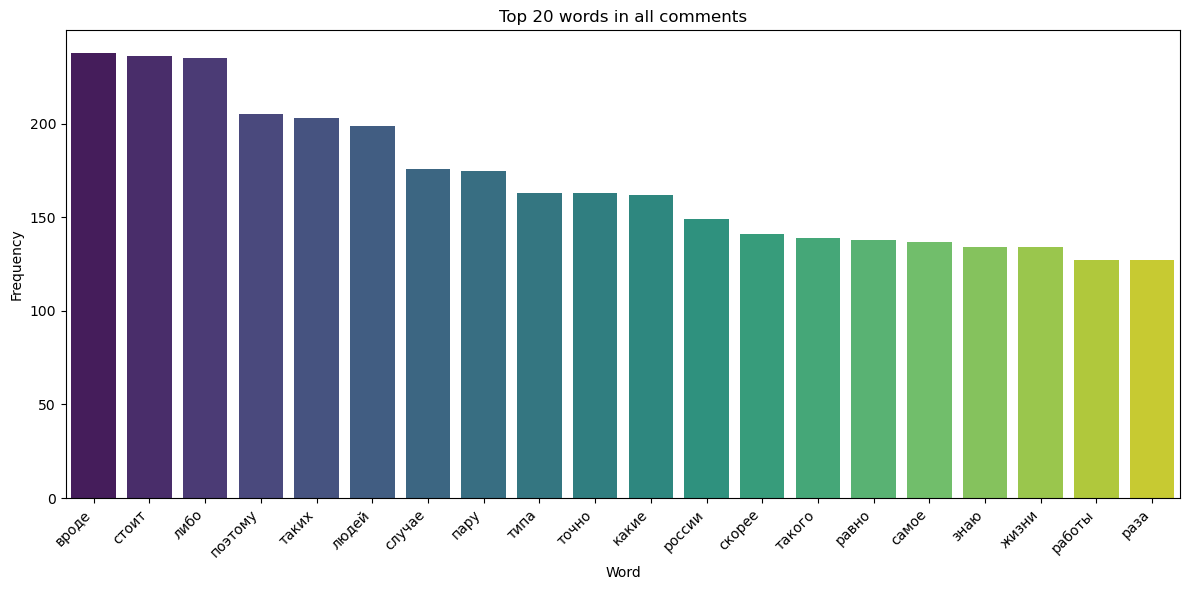

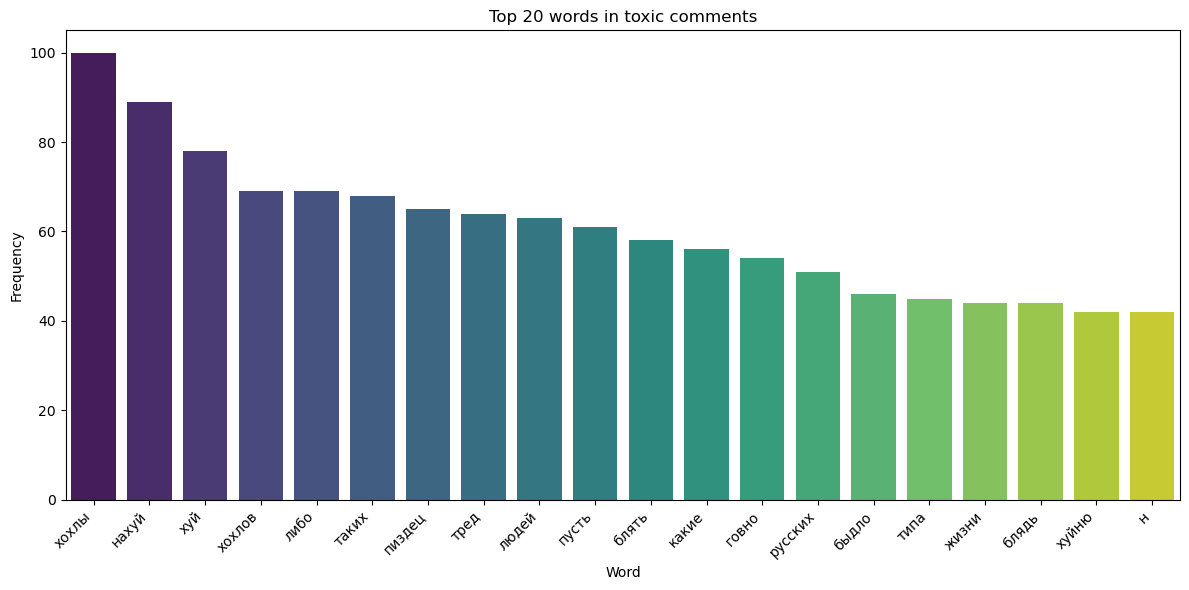

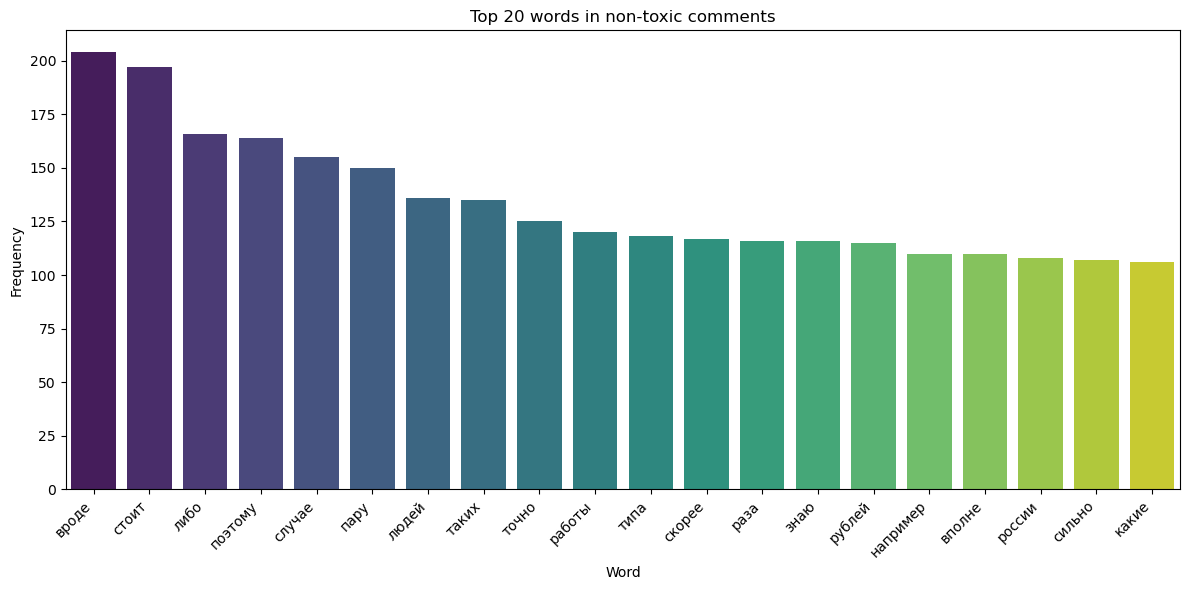

In [17]:
def plot_word_frequency(word_list, title):
    words, counts = zip(*word_list)
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=list(words),
        y=list(counts),
        hue=list(words),
        palette='viridis',
        legend=False
    )
    plt.title(title)
    plt.xlabel('Word')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_word_frequency(top_words_all, 'Top 20 words in all comments')
plot_word_frequency(top_words_toxic, 'Top 20 words in toxic comments')
plot_word_frequency(top_words_non_toxic, 'Top 20 words in non-toxic comments')

**Conclusion.** Analysis of the most frequent words reveals clear differences between toxic and non-toxic comments. Toxic comments are characterized by offensive and obscene vocabulary, whereas non-toxic comments are dominated by neutral and general-purpose words.

## Tokenization Analysis

In [18]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

In [19]:
df['token_length'] = df['comment'].apply(
    lambda text: len(tokenizer.encode(text, add_special_tokens=True))
)

In [20]:
df['token_length'].describe()

count    14412.000000
mean        43.276506
std         60.659383
min          5.000000
25%         16.000000
50%         27.000000
75%         48.000000
max       1753.000000
Name: token_length, dtype: float64

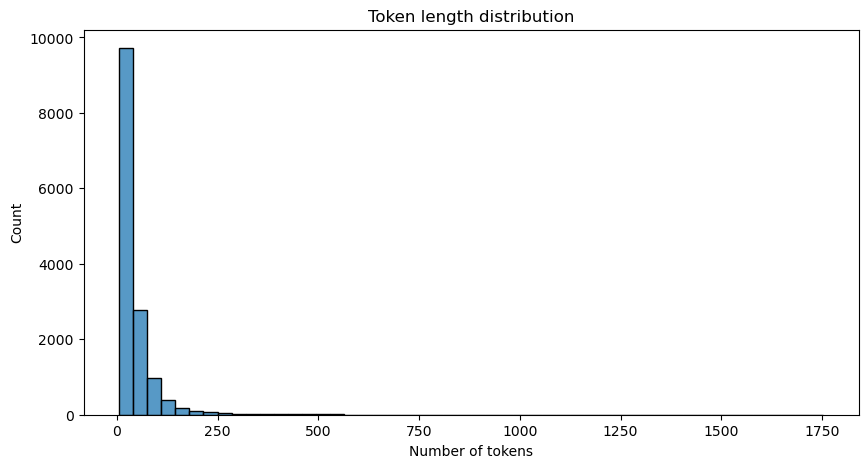

In [21]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['token_length'],
    bins=50
)

plt.title("Token length distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Count")
plt.show()

### Percentiles

In [22]:
for p in [50, 90, 95, 99]:
    print(
        f"{p}% comments <= "
        f"{df['token_length'].quantile(p / 100):.0f} tokens"
    )

50% comments <= 27 tokens
90% comments <= 87 tokens
95% comments <= 124 tokens
99% comments <= 268 tokens


In [23]:
percentiles = [50, 75, 90, 95, 99]

for p in percentiles:
    value = df["token_length"].quantile(p / 100)
    print(f"{p}%: {value:.0f}")

50%: 27
75%: 48
90%: 87
95%: 124
99%: 268


**Conclusion.** After RuBERT tokenization, the median comment length is 27 tokens. Furthermore, 90% of comments contain no more than 87 tokens, 95% contain no more than 124 tokens, and 99% contain no more than 268 tokens. Based on this analysis, max_length = 128 was selected for all subsequent experiments, covering approximately 95% of comments while maintaining computational efficiency.

## Split into train/val/test

In [24]:
df = df.drop(columns=['word_count', 'unique_word_count', 'token_length'])
df = df.rename(columns={'toxic': 'labels'})
df['labels'] = df['labels'].astype(int)

In [25]:
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42, stratify=df['labels'])
train_df, val_df = train_test_split(train_df, test_size=0.11111, random_state=42, stratify=train_df['labels'])

In [26]:
train_df.to_csv('../data/train.csv', index=False)
val_df.to_csv('../data/val.csv', index=False)
test_df.to_csv('../data/test.csv', index=False)

**Conclusion.** The dataset was split into training, validation, and test subsets using an 80/10/10 stratified split. This approach preserves the original class distribution across all subsets and ensures a fair comparison of the evaluated models.